# **Movie Dataset Visualization Assessment Part 2**



*   Name: Feven Abebe
*   ID:qiyas-2026-003641

In [ ]:
# Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mounrt to access files from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Specify the file driectory
%cd "/content/drive/MyDrive/"

/content/drive/MyDrive


In [26]:
# DataFrame csv
movies=pd.DataFrame(pd.read_csv("movies_updated.csv"))

## **Exercise 1**

In [27]:
#Create a new feature called ROI:
movies["ROI"]= (movies["gross"]-movies["budget"])/movies["budget"]
movies.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,",ROI
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,",1.473620
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,",12.078468
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,",28.909726
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,"88.0,",22.843868
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,"98.0,",5.641057


In [28]:
#Remove movies with missing values in budget , gross , or score .
movies = movies.dropna(subset=["budget", "gross", "score"])
movies = movies[movies["budget"] > 0]

##### **Visualization Justification**
A bubble chart was used because it allows multiple variables to be visualized in a single figure. The x-axis and y-axis show relationships between key metrics, while bubble size and color represent additional variables

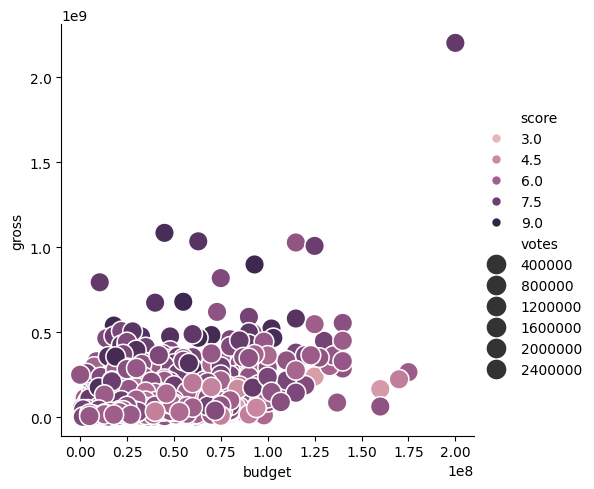

In [29]:
#Create a scatter plot that simultaneously shows:
sns.relplot(x="budget",
            y="gross",
            hue="score",
            size="votes",
            sizes=(200, 200),
            data=movies)

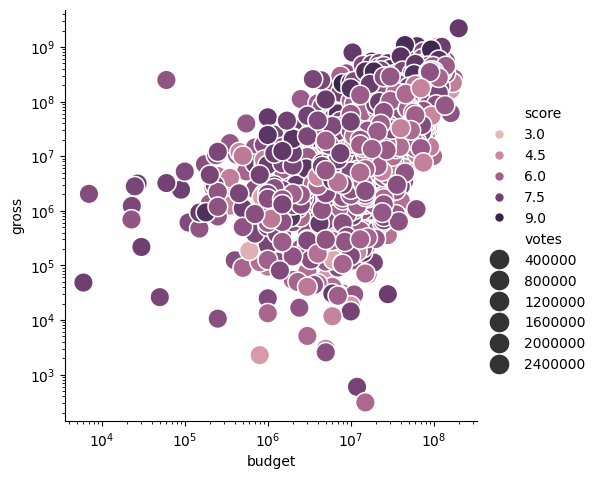

In [ ]:
# Apply appropriate transformations if necessary to improve readability.
sns.relplot(x="budget",
            y="gross",
            hue="score",
            size="votes",
            sizes=(200, 200),
            data=movies)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [31]:
top_10_roi = movies.sort_values("ROI", ascending=False).head(10)
top_10_roi

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,",ROI
3459,The Blair Witch Project,R,Horror,1999,"July 30, 1999 (United States)",6.5,239000,Daniel Myrick,Daniel Myrick,Heather Donahue,United States,60000,248639099.0,Haxan Films,"81.0,",4142.984983
2093,El Mariachi,R,Action,1992,"February 26, 1993 (United States)",6.9,64000,Robert Rodriguez,Robert Rodriguez,Carlos Gallardo,Mexico,7000,2040920.0,Columbia Pictures,"81.0,",290.560000
2467,Clerks,R,Comedy,1994,"November 9, 1994 (France)",7.7,214000,Kevin Smith,Kevin Smith,Brian O'Halloran,United States,27000,3151130.0,View Askew Productions,"92.0,",115.708519
3233,In the Company of Men,R,Comedy,1997,"August 1, 1997 (United States)",7.2,13000,Neil LaBute,Neil LaBute,Aaron Eckhart,Canada,25000,2804473.0,Alliance Atlantis Communications,"97.0,",111.178920
209,E.T. the Extra-Terrestrial,PG,Family,1982,"June 11, 1982 (United States)",7.8,381000,Steven Spielberg,Melissa Mathison,Henry Thomas,United States,10500000,792910554.0,Universal Pictures,"115.0,",74.515291
3089,The Full Monty,R,Comedy,1997,"September 19, 1997 (United States)",7.2,101000,Peter Cattaneo,Simon Beaufoy,Robert Carlyle,United Kingdom,3500000,257938649.0,Redwave Films,"91.0,",72.696757
5,Friday the 13th,R,Horror,1980,"May 9, 1980 (United States)",6.4,123000,Sean S. Cunningham,Victor Miller,Betsy Palmer,United States,550000,39754601.0,Paramount Pictures,"95.0,",71.281093
2458,Four Weddings and a Funeral,R,Comedy,1994,"April 15, 1994 (United States)",7.1,144000,Mike Newell,Richard Curtis,Hugh Grant,United Kingdom,4400000,245700832.0,PolyGram Filmed Entertainment,"117.0,",54.841098
3291,Pi,R,Drama,1998,"July 10, 1998 (United States)",7.4,173000,Darren Aronofsky,Darren Aronofsky,Sean Gullette,United States,60000,3221152.0,Harvest Filmworks,"84.0,",52.685867
1684,Slacker,R,Comedy,1990,"July 5, 1991 (United States)",7.1,20000,Richard Linklater,Richard Linklater,Richard Linklater,United States,23000,1228108.0,Detour Filmproduction,"97.0,",52.396000


##### **Visualization Justification**
A bubble chart was used because it allows multiple variables to be visualized in a single figure. The x-axis and y-axis show relationships between key metrics, while bubble size and color represent additional variables

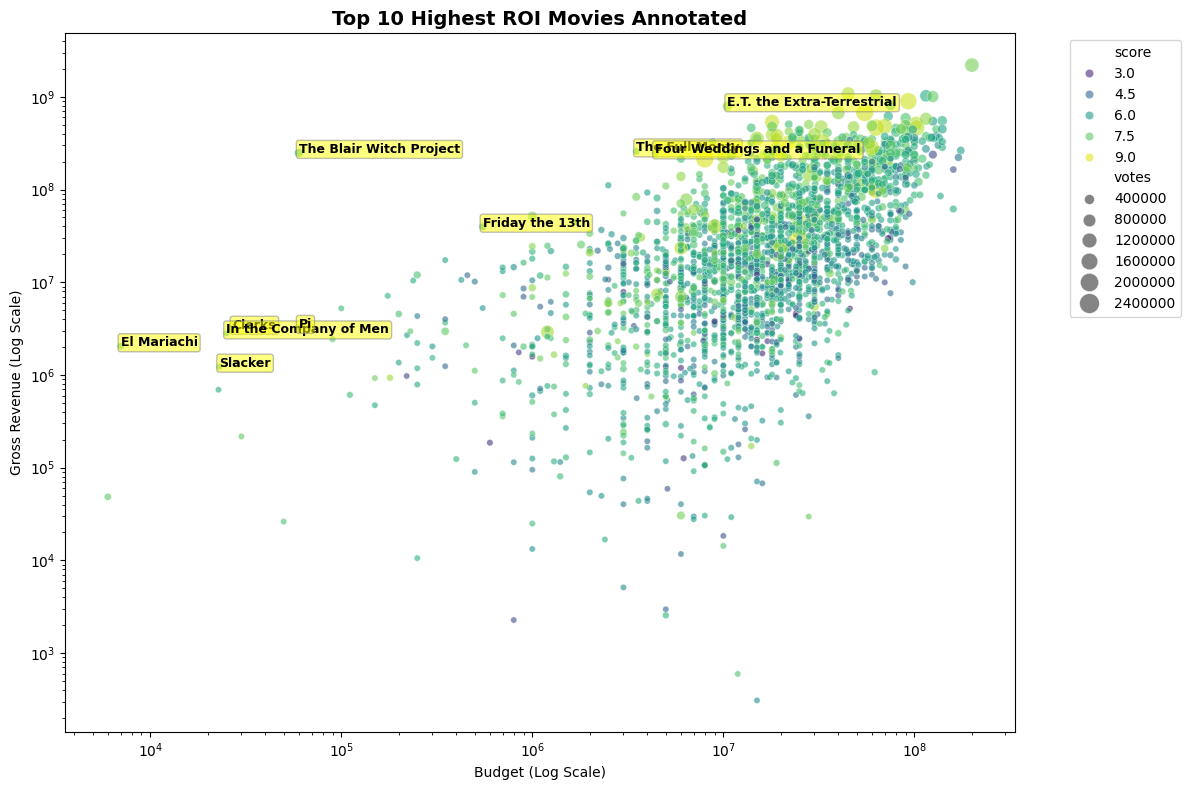

In [32]:
#Annotate the 10 movies with the highest ROI
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=movies,
    x="budget",
    y="gross",
    hue="score",
    size="votes",
    palette="viridis",
    sizes=(20, 200),
    alpha=0.6
)
# Loop through the top 10 movies and add text annotations
for index, row in top_10_roi.iterrows():
    plt.annotate(
        text=row['name'],
        xy=(row['budget'], row['gross']),
        fontsize=9,
        weight='bold',
        color='black',
        bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.5, ec="gray")
    )
plt.xscale('log')
plt.yscale('log')

# 6. Labels and layout
plt.title("Top 10 Highest ROI Movies Annotated", fontsize=14, weight="bold")
plt.xlabel("Budget (Log Scale)")
plt.ylabel("Gross Revenue (Log Scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [38]:
#Identify  the 10 movies with the highest ROI.
top_genres = movies["genre"].value_counts().head(10).index
genre_df = movies[movies["genre"].isin(top_genres)]

##### **Visualization Justification**
A box plot was chosen because the task asks to compare ROI distributions across genres.

Unlike a bar chart, a box plot shows:Median ROI, Variability,Outliers

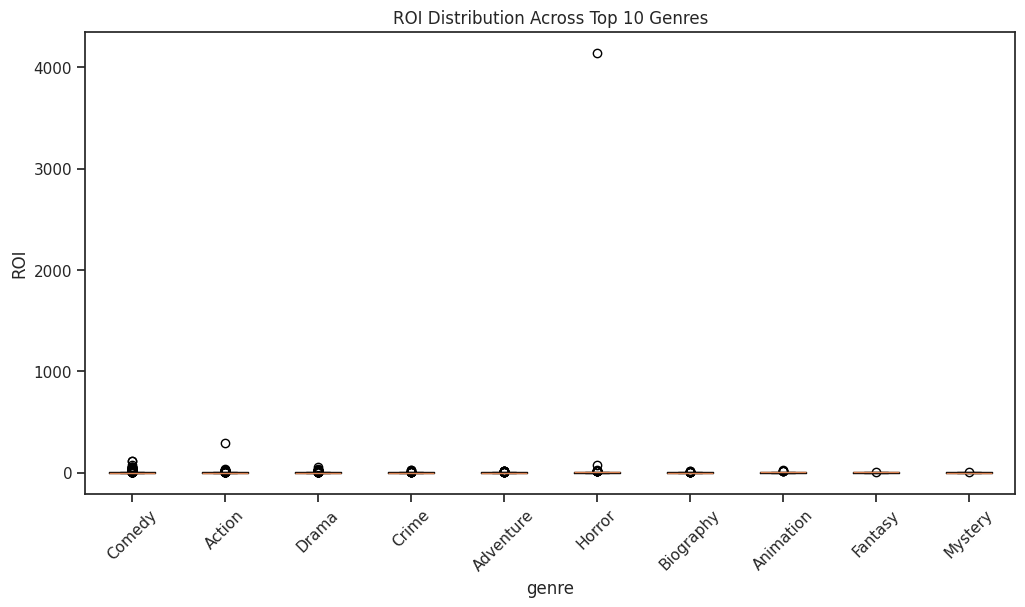

In [82]:
#Annotate the 10 movies with the highest ROI.
data = [genre_df[genre_df["genre"] == g]["ROI"] for g in top_genres]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=top_genres)

plt.xticks(rotation=45)
plt.xlabel("genre")
plt.ylabel("ROI")
plt.title("ROI Distribution Across Top 10 Genres")
plt.show()

Questions


Do larger budgets generally result in higher revenue?


*   Yes

Which genre appears to generate the highest returns relative to investment?

*   Horror and Action, but horror might be an outliner

Are highly rated movies always financially successful?


*   No, they are not guaranteed financial success



## **Exercise 2**

In [40]:
#1 Directors with at least 5 movies.
director_counts = movies['director'].value_counts()
directors_with_5_movies = director_counts[director_counts >= 5]
directors_with_5_movies.head()

,count
director,
Woody Allen,20
Clint Eastwood,16
Barry Levinson,15
Steven Spielberg,14
John Carpenter,14


In [41]:
#1 Companies with at least 20 movies.
company_counts = movies['company'].value_counts()
companies_with_20_movies = company_counts[company_counts >= 20]
companies_with_20_movies.head()

,count
company,
Universal Pictures,151
Paramount Pictures,151
Columbia Pictures,145
Warner Bros.,133
Twentieth Century Fox,95


In [51]:
#2 For each director, calculate: Number of Movies Average Score Median Score Standard Deviation of Score
director_counts = movies['director'].value_counts()
valid_directors = director_counts[director_counts >= 5].index
director_movies = movies[movies['director'].isin(valid_directors)]
director_movies['director'].value_counts().min()
director_stats = (
    director_movies
    .groupby('director')
    .agg(
        Number_of_Movies=('score', 'count'),
        Average_Score=('score', 'mean'),
        Median_Score=('score', 'median'),
        Std_Score=('score', 'std')
    )
)

director_stats.head()

,Number_of_Movies,Average_Score,Median_Score,Std_Score
director,,,,
Abel Ferrara,5,6.460000,6.60,0.646529
Adrian Lyne,6,6.583333,6.55,0.611283
Alan J. Pakula,6,6.400000,6.40,0.807465
Alan Parker,10,7.110000,7.30,0.662403
Alan Rudolph,5,5.980000,6.40,0.867179


#### **Visualization Justification**
A bubble chart was used because it allows multiple variables to be visualized in a single figure. The x-axis and y-axis show relationships between key metrics, while bubble size and color represent additional variables

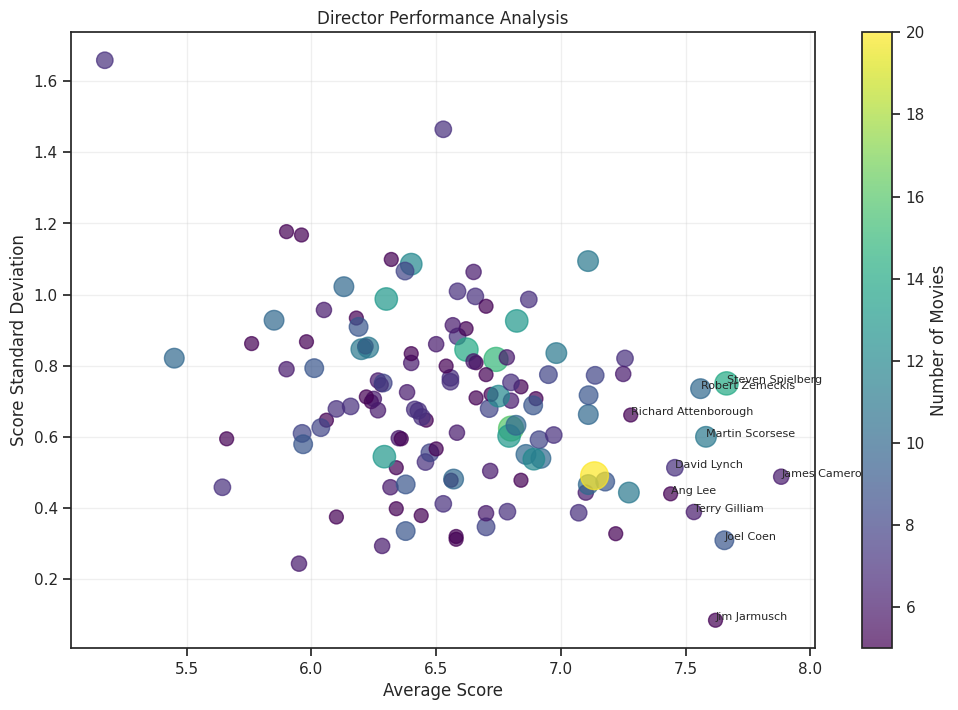

In [115]:
#3. Create a visualization that helps distinguish:
#Consistently high-performing directors
#Inconsistent directors
#Highly productive directors
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    director_stats['Average_Score'],
    director_stats['Std_Score'],
    s=director_stats['Number_of_Movies'] * 20,
    c=director_stats['Number_of_Movies'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(label='Number of Movies')

top_consistent = director_stats.sort_values(
    ['Average_Score', 'Std_Score'],
    ascending=[False, True]
).head(10)

for director, row in top_consistent.iterrows():
    plt.annotate(
        director,
        (row['Average_Score'], row['Std_Score']),
        fontsize=8
    )

plt.xlabel('Average Score')
plt.ylabel('Score Standard Deviation')
plt.title('Director Performance Analysis')
plt.grid(True, alpha=0.3)

plt.show()

#### **Visualization Justification**
A bubble chart was used because it allows multiple variables to be visualized in a single figure. The x-axis and y-axis show relationships between key metrics, while bubble size and color represent additional variables

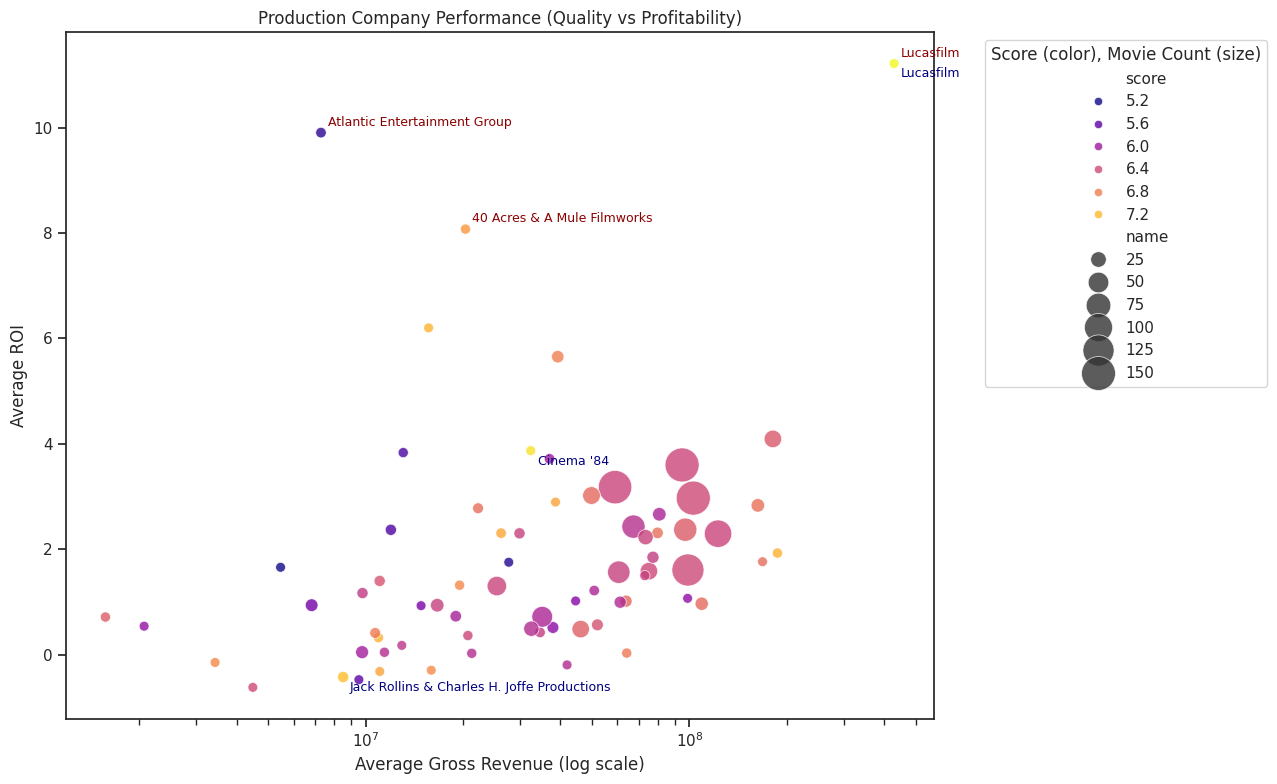

In [127]:
# Create dataset (only reliable companies)
frequent_companies = company_stats[company_stats['name'] >= 5].copy()

plt.figure(figsize=(13,8))

# Main bubble chart
scatter = sns.scatterplot(
    data=frequent_companies,
    x='gross',
    y='ROI',
    hue='score',
    size='name',
    palette='plasma',
    sizes=(50,600),
    alpha=0.8
)

plt.xscale('log')

plt.title('Production Company Performance (Quality vs Profitability)')
plt.xlabel('Average Gross Revenue (log scale)')
plt.ylabel('Average ROI')


# ----------------------------
# Identify top companies
# ----------------------------

top_profit = frequent_companies.nlargest(3, 'ROI')
top_quality = frequent_companies.nlargest(3, 'score')

# ----------------------------
# Annotate PROFIT leaders
# ----------------------------
for _, row in top_profit.iterrows():
    plt.annotate(
        row['company'],
        (row['gross'], row['ROI']),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=9,
        color='darkred'
    )

# ----------------------------
# Annotate QUALITY leaders
# ----------------------------
for _, row in top_quality.iterrows():
    plt.annotate(
        row['company'],
        (row['gross'], row['ROI']),
        textcoords="offset points",
        xytext=(5,-10),
        fontsize=9,
        color='navy'
    )

# ----------------------------
# Clear legend for interpretation
# ----------------------------
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Score (color), Movie Count (size)"
)

plt.tight_layout()
plt.show()



In [130]:
#Quality rank
quality_rank = frequent_companies.sort_values(
    ['score', 'ROI'],
    ascending=[False, False]
)

quality_rank.head(10)

,company,gross,ROI,score,name
512,Lucasfilm,4.289355e+08,11.214172,7.560000,5
212,Cinema '84,3.237683e+07,3.870341,7.440000,5
460,Jack Rollins & Charles H. Joffe Productions,8.526666e+06,-0.425327,7.222222,9
381,Good Machine,1.565760e+07,6.199254,7.160000,5
757,Walt Disney Animation Studios,1.871638e+08,1.926975,7.150000,6
207,CiBy 2000,1.095957e+07,0.321731,7.150000,6
709,The Ladd Company,2.622288e+07,2.304627,7.071429,7
706,The Geffen Company,3.861531e+07,2.894296,7.060000,5
778,Zoetrope Studios,1.106553e+07,-0.319050,7.060000,5
8,40 Acres & A Mule Filmworks,2.035638e+07,8.072919,6.983333,6


In [131]:
#Profit rank
profit_rank = frequent_companies.sort_values(
    ['ROI', 'score'],
    ascending=[False, False]
)

profit_rank.head(10)

,company,gross,ROI,score,name
512,Lucasfilm,4.289355e+08,11.214172,7.560000,5
84,Atlantic Entertainment Group,7.283213e+06,9.903027,5.314286,7
8,40 Acres & A Mule Filmworks,2.035638e+07,8.072919,6.983333,6
381,Good Machine,1.565760e+07,6.199254,7.160000,5
621,PolyGram Filmed Entertainment,3.922814e+07,5.652317,6.807692,13
758,Walt Disney Pictures,1.811705e+08,4.092513,6.523529,34
212,Cinema '84,3.237683e+07,3.870341,7.440000,5
165,Cannon Films,1.307338e+07,3.832672,5.483333,6
379,Golden Harvest Company,3.700053e+07,3.715141,6.000000,7
601,Paramount Pictures,9.498667e+07,3.598430,6.375497,151


Question
Identify three directors who are consistently successful.

*  Based on average movie ratings and score variability, James Cameron, Joel Coen, and Jim Jarmusch appear to be the most consistently successful directors. All three have high average scores above 7.6 and relatively low standard deviations,

Identify companies that prioritize quality over profitability.

* Lucasfilm → 7.56 score, ROI 11.21
* Cinema '84 → 7.44 score, ROI 3.87
* Jack Rollins & Charles H. Joffe → 7.22 score, ROI -0.43

Identify companies that prioritize profitability over quality.

*  Lucasfilm → ROI 11.21, score 7.56
* Atlantic Entertainment Group → ROI 9.90, score 5.31
* 40 Acres & A Mule → ROI 8.07, score 6.98

## **Exercise 3**

In [65]:
# Create decade groups from the movie release year.
movies['decade'] = (movies['year'] // 10) * 10
movies['decade']

,decade
0,1980
1,1980
2,1980
3,1980
4,1980
...,...
3994,2000
3995,2000
3997,2000
3998,2000


In [66]:
#For each decade and genre, calculate:Number of Movies, Average Score, Total Gross Revenue
genre_decade_stats = (
    movies
    .groupby(['decade', 'genre'])
    .agg(
        Number_of_Movies=('name', 'count'),
        Average_Score=('score', 'mean'),
        Total_Gross=('gross', 'sum')
    )
    .reset_index()
)

genre_decade_stats.head()

,decade,genre,Number_of_Movies,Average_Score,Total_Gross
0,1980,Action,222,6.193243,1.083790e+10
1,1980,Adventure,72,6.156944,2.502041e+09
2,1980,Animation,19,7.126316,9.526155e+08
3,1980,Biography,33,7.100000,1.160968e+09
4,1980,Comedy,278,6.266187,8.896916e+09


#### **Visualization Justification**
A line graph was used as we are dealing with trend analysis and muliple catagories can be represented by d/f line

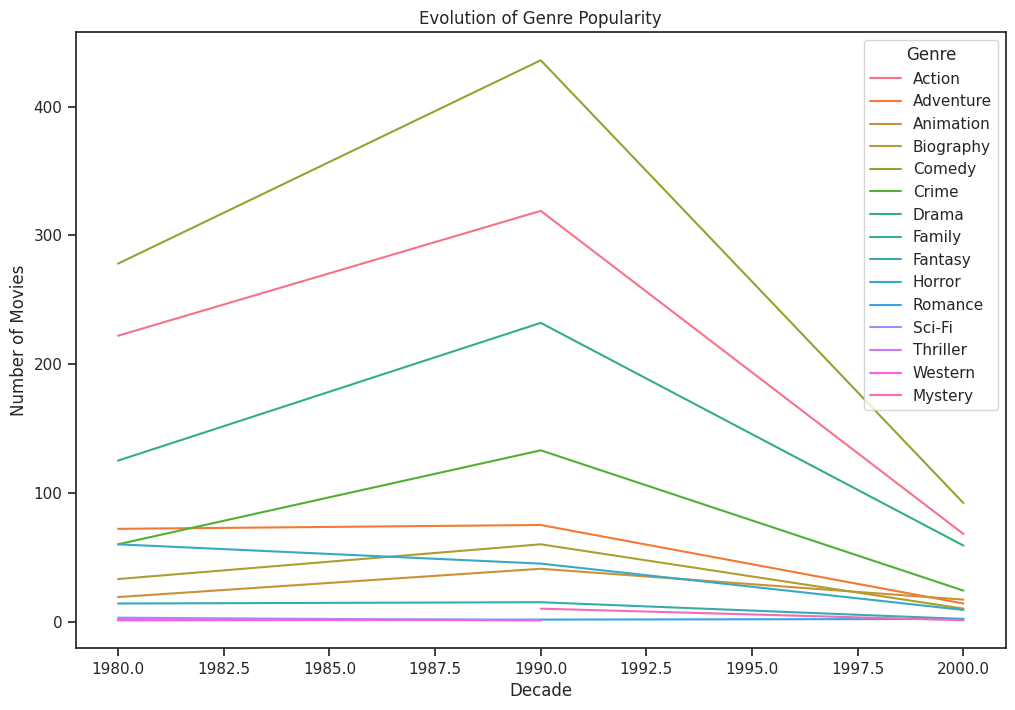

In [114]:
#Build a visualization that clearly shows how genre popularity evolved across decades.
plt.figure(figsize=(12,8))

sns.lineplot(
    data=genre_decade_stats,
    x='decade',
    y='Number_of_Movies',
    hue='genre'
)

plt.title('Evolution of Genre Popularity')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.legend(title='Genre')

plt.show()

In [69]:
#Consider only countries with at least 30 movies.
country_counts = movies['country'].value_counts()
valid_countries = country_counts[country_counts >= 30].index
country_movies = movies[
    movies['country'].isin(valid_countries)
]
country_movies

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,",ROI,decade
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,",1.473620,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,",12.078468,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,",28.909726,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,"88.0,",22.843868,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,"98.0,",5.641057,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,O,R,Drama,2001,"August 31, 2001 (United States)",6.1,19000,Tim Blake Nelson,William Shakespeare,Mekhi Phifer,United States,5000000,19260537.0,Chickie the Cop,"95.0,",2.852107,2000
3995,Birthday Girl,R,Comedy,2001,"February 1, 2002 (United States)",6.1,25000,Jez Butterworth,Tom Butterworth,Nicole Kidman,United Kingdom,13000000,16171098.0,FilmFour,"93.0,",0.243931,2000
3997,Made,R,Comedy,2001,"August 31, 2001 (United States)",6.4,18000,Jon Favreau,Jon Favreau,Vince Vaughn,United States,5000000,5480653.0,Artisan Entertainment,"95.0,",0.096131,2000
3998,One Night at McCool's,R,Comedy,2001,"April 27, 2001 (United States)",6.1,29000,Harald Zwart,Stan Seidel,Liv Tyler,United States,18000000,13578186.0,October Films,"93.0,",-0.245656,2000


In [70]:
#For each country, calculate:Average Score, Average Budget, Average Gross Revenue,Average ROI
country_stats = (
    country_movies
    .groupby('country')
    .agg(
        Average_Score=('score','mean'),
        Average_Budget=('budget','mean'),
        Average_Gross=('gross','mean'),
        Average_ROI=('ROI','mean')
    )
    .reset_index()
)

country_stats.head()

,country,Average_Score,Average_Budget,Average_Gross,Average_ROI
0,Canada,5.868182,1.378130e+07,1.641894e+07,3.821059
1,France,6.653488,2.969767e+07,3.671473e+07,0.396613
2,United Kingdom,6.520488,1.978217e+07,3.672382e+07,1.412941
3,United States,6.321415,2.484979e+07,6.177427e+07,4.032670


#### **Visualization Justification**
A bubble chart was used because it allows multiple variables to be visualized in a single figure. The x-axis and y-axis show relationships between key metrics, while bubble size and color represent additional variables

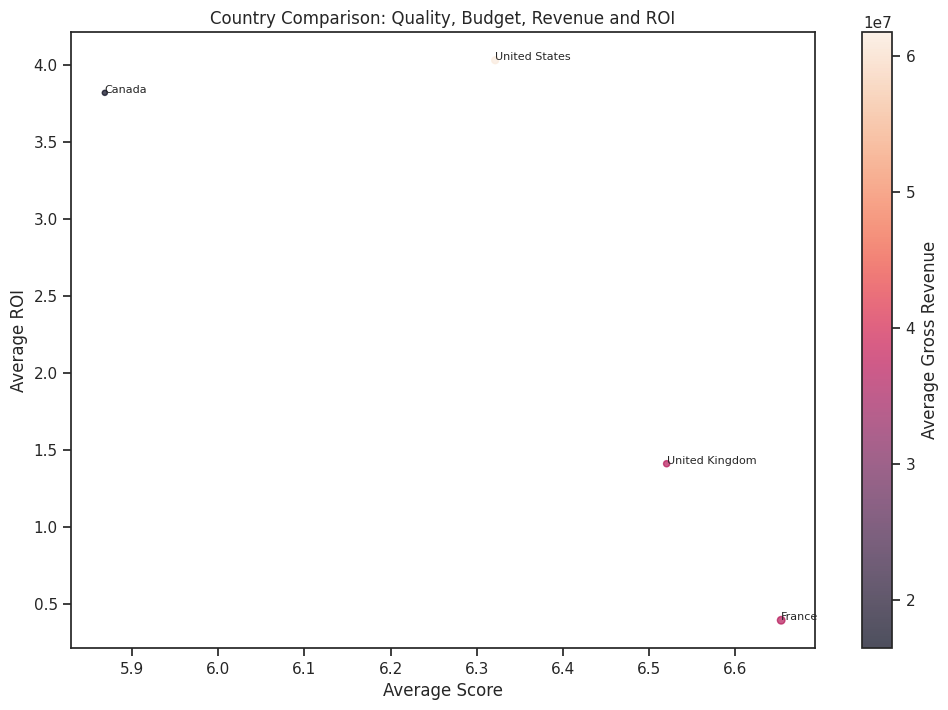

In [112]:
# Create a single visualization that compares countries using all four metrics

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    country_stats['Average_Score'],      # Quality
    country_stats['Average_ROI'],        # Profitability
    s=country_stats['Average_Budget']/1e6,  # Budget (bubble size)
    c=country_stats['Average_Gross'],       # Gross revenue (color)
    alpha=0.7
)

# Select top countries based on score and ROI
top_countries = country_stats.sort_values(
    ['Average_Score', 'Average_ROI'],
    ascending=False
).head(8)

for i, row in top_countries.iterrows():
    plt.annotate(
        row['country'],
        (row['Average_Score'], row['Average_ROI']),
        fontsize=8
    )

plt.xlabel('Average Score')
plt.ylabel('Average ROI')
plt.title('Country Comparison: Quality, Budget, Revenue and ROI')

plt.colorbar(
    scatter,
    label='Average Gross Revenue'
)


plt.show()

In [73]:
median_votes = movies['votes'].median()
median_votes

25000.0

In [75]:
#Define a Hidden Gem
movies['Hidden_Gem'] = (
    (movies['score'] >= 8)
    &
    (movies['votes'] < median_votes)
)
movies['Hidden_Gem']

,Hidden_Gem
0,False
1,False
2,False
3,False
4,False
...,...
3994,False
3995,False
3997,False
3998,False


In [81]:
#Define hidden_gem
hidden_gems = movies[
    movies['Hidden_Gem']
]
hidden_gems.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,",ROI,decade,Hidden_Gem
724,Mishima: A Life in Four Chapters,R,Biography,1985,"September 20, 1985 (United States)",8.0,10000,Paul Schrader,Paul Schrader,Ken Ogata,United States,5000000,569996.0,Zoetrope Studios,"120.0,",-0.886001,1980,True
2625,Pred dozhdot,Not Rated,Drama,1994,"February 24, 1995 (United States)",8.0,14000,Milcho Manchevski,Milcho Manchevski,Katrin Cartlidge,Republic of Macedonia,1900000,763847.0,Aim,"113.0,",-0.597975,1990,True


In [78]:
#Calculate the number of hidden gems produced by each genre and country.
genre_gems = (
    hidden_gems
    .groupby('genre')
    .size()
    .reset_index(name='Hidden_Gems')
)

genre_gems

,genre,Hidden_Gems
0,Biography,1
1,Drama,1


In [79]:
#Create a visualization that highlights where hidden gems are most commonly found.
country_gems = (
    hidden_gems
    .groupby('country')
    .size()
    .reset_index(name='Hidden_Gems')
)

country_gems

,country,Hidden_Gems
0,Republic of Macedonia,1
1,United States,1


#### **Visualization Justification**
A bar graph was used as we are comparing a single numerical value (number of hidden gems) across multiple categories (countries)

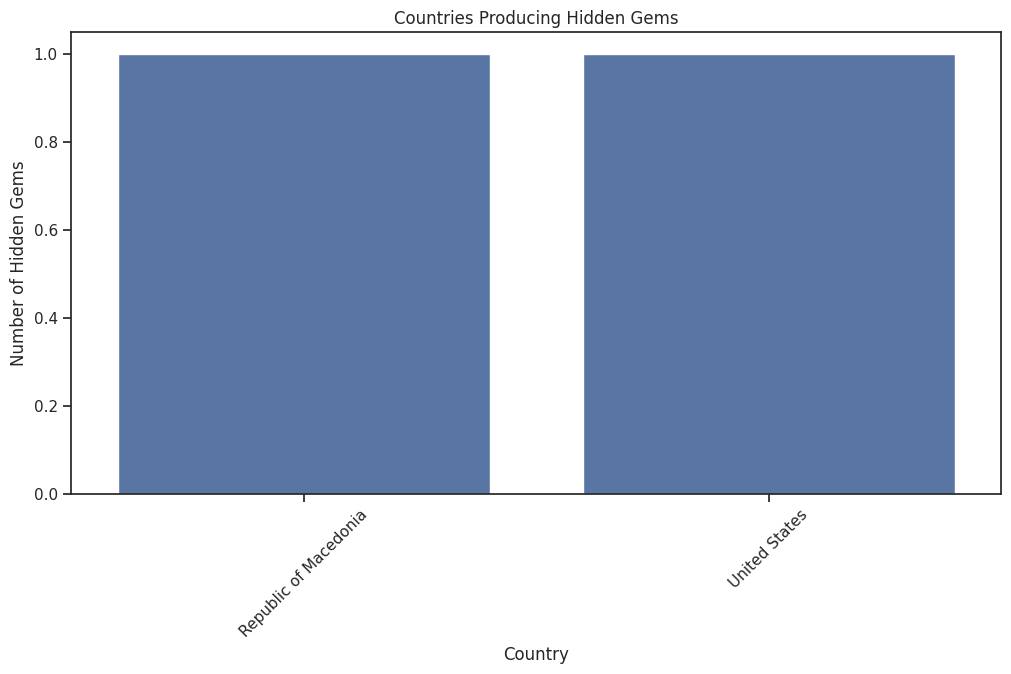

In [113]:
#Create a visualization that highlights where hidden gems are most commonly found.
country_gems = country_gems.sort_values(
    'Hidden_Gems',
    ascending=False
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=country_gems.head(15),
    x='country',
    y='Hidden_Gems'
)
plt.xticks(rotation=45)
plt.title('Countries Producing Hidden Gems')
plt.xlabel('Country')
plt.ylabel('Number of Hidden Gems')
plt.show()

Questions

Which genres gained popularity over time?


*   Comedy


Which countries produce the highest-quality movies relative to budget?
*  France and United Kingdome

Which genre and country combinations appear to be the most underrated by
audiences?

*   United States(biography) and Republic of Macedonia(drama)